In [ ]:
from preprocessing import fold_split_data, get_data, get_encoded_data, split_data

features, target = get_data()
encoded_features, target = get_encoded_data(features, target)
X, X_valid, X_test, y, y_valid, y_test = split_data(encoded_features, target)


In [ ]:
import numpy as np
from lightgbm import LGBMClassifier

preds = []
folds = fold_split_data(X, y)
for i, (train_idx, valid_idx) in enumerate(folds):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]
    print(f"Fold {i+1}")
    model = LGBMClassifier(
        random_state=42,
        force_col_wise=True,
        max_depth=10,
        num_leaves=52,
        n_estimators=140,
        learning_rate=0.01,
        # is_unbalance=True,
        # class_weight='balanced',
        scale_pos_weight=5,
    )

    model.fit(X_train, y_train)
    valid_pred = model.predict(X_valid)
    valid_pred_proba = model.predict_proba(X_valid)[:, 1]

    preds.append(valid_pred_proba)

results = np.mean(np.column_stack(preds), axis=1)
final_pred = (results >= 0.4).astype(int)

Fold 1
[LightGBM] [Info] Number of positive: 915, number of negative: 3585
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 4500, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203333 -> initscore=-1.365590
[LightGBM] [Info] Start training from score -1.365590
Fold 2
[LightGBM] [Info] Number of positive: 933, number of negative: 3567
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] Number of data points in the train set: 4500, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.207333 -> initscore=-1.341075
[LightGBM] [Info] Start training from score -1.341075
Fold 2
[LightGBM] [Info] Number of positive: 933, number of negative: 3567
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] Number of data points in the train set: 4500, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.207333 -> initscore=-1.341075
[LightGBM] [Info] Start training from score -1.34107

In [29]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(y_valid, final_pred)
f1 = f1_score(y_valid, final_pred)
recall = recall_score(y_valid, final_pred)
precision = precision_score(y_valid, final_pred)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

Validation 성능 - Accuracy: 0.6916, F1 Score: 0.3514, Recall: 0.4000, Precision: 0.3133


/Users/tera/Desktop/workspace/skn_21/project/project_02/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


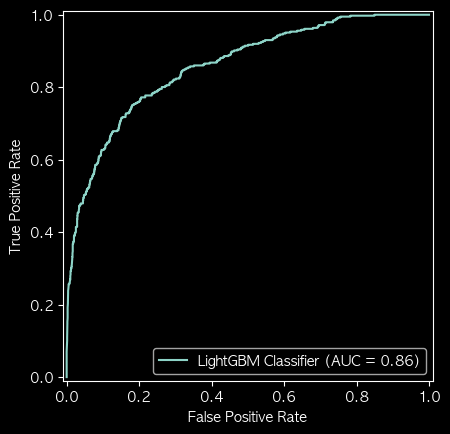

In [5]:

from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

rfc_roc = roc_auc_score(y_valid, valid_pred_proba)
fpr, recall, thresh = roc_curve(y_valid, valid_pred_proba)
disp_roc_rfc = RocCurveDisplay(
    fpr=fpr, tpr=recall,
    roc_auc=rfc_roc,
    estimator_name='LightGBM Classifier'
)
disp_roc_rfc.plot()


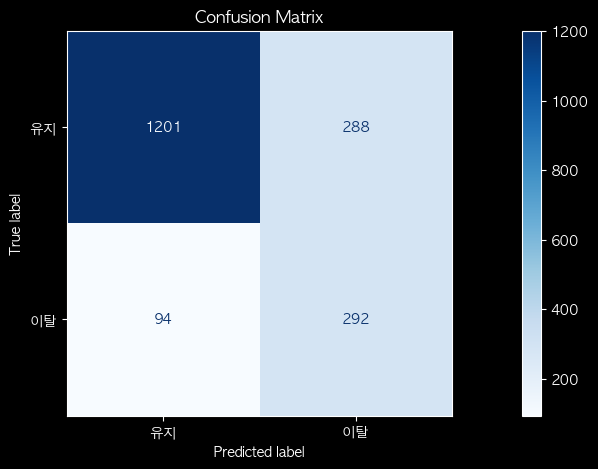

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots( figsize=(18, 5))

cm = confusion_matrix(y_valid, valid_pred)
ConfusionMatrixDisplay(cm, display_labels=['유지', '이탈']).plot(ax=axes, cmap='Blues')
axes.set_title('Confusion Matrix')

plt.show()

In [24]:
# 오버샘플링을 해봤지만 성능에 큰 향상이 없었음.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    random_state=42,
    force_col_wise=True,
    num_leaves=100,
    n_estimators=300,
    learning_rate=0.01,
    class_weight='balanced',
    objective='binary',
    # scale_pos_weight=4,
)
model.fit(X_train_over, y_train_over)
valid_pred = model.predict(X_valid)
valid_pred_proba = model.predict_proba(X_valid)[:, 1]

[LightGBM] [Info] Number of positive: 4471, number of negative: 4471
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 8942, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [48]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)
recall = recall_score(y_valid, valid_pred)
precision = precision_score(y_valid, valid_pred)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

Validation 성능 - Accuracy: 0.8496, F1 Score: 0.5971, Recall: 0.5415, Precision: 0.6656
